# Legendre truncation

#### Import general modules

mpi4py is always required when using these tools. Numpy is always good to have if any manipulation is to be done.

In [50]:
# Import required modules
from mpi4py import MPI #equivalent to the use of MPI_init() in C
import matplotlib.pyplot as plt
import numpy as np

# Get mpi info
comm = MPI.COMM_WORLD

import os
os.environ["PYSEMTOOLS_DEBUG"] = 'false'
os.environ["PYSEMTOOLS_HIDE_LOG"] = 'false'

def get_folder_size(folder):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size

#### Import modules from pysemtools

In this case we will import all the data types that we currently support, as well as io functions that are required to populate them.

In [51]:
# Data types
from pysemtools.datatypes.msh import Mesh
from pysemtools.datatypes.coef import Coef
from pysemtools.datatypes.field import Field, FieldRegistry

# Readers
from pysemtools.io.ppymech.neksuite import preadnek, pynekread

# Writers
from pysemtools.io.ppymech.neksuite import pwritenek, pynekwrite

fname = '../../data/mixlay0.f00001'

## Read the data

In [52]:
# Read the data
msh = Mesh(comm, create_connectivity=False)
fld = FieldRegistry(comm)
pynekread(fname, comm, data_dtype=np.single, msh = msh, fld = fld)
pynekwrite("test_no_mesh", comm, msh = msh, fld = fld, write_mesh=False)
 
# Get the coefficients
coef = Coef(msh=msh, comm=comm)

2026-08-06 15:20:04,204  pynekread             INFO      Reading file: ../../data/mixlay0.f00001
2026-08-06 15:20:04,212  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.005733081000016682s
2026-08-06 15:20:04,215  Field                 INFO      Field registry updated with: ['u', 'v', 'p', 't', 's0', 's1'] - dtype: float32
2026-08-06 15:20:04,216  pynekread             INFO      File successfully read - Elapsed time: 0.011995789999900808s
2026-08-06 15:20:04,216  pynekwrite            INFO      Writing file: test_no_mesh
2026-08-06 15:20:04,219  pynekwrite            INFO      File written - Elapsed time: 0.002496983000128239s
2026-08-06 15:20:04,225  Coef                  INFO      Coef object initialized - dtype: float32 - Elapsed time: 0.005170091000081811s


[adperez][[41123,1],0][../../../../../../opal/mca/btl/tcp/btl_tcp.c:559:mca_btl_tcp_recv_blocking] recv(115) failed: Connection reset by peer (104)


## Compress the data with Legendre BP V1

### Initialize the compressor

In [53]:
from pysemtools.compression.legendre_truncation_bitplane import DiscreetLegendreTruncationBP

# Initialize the original Bitplane V1 compressor
dlt_bp = DiscreetLegendreTruncationBP(comm=comm, msh=msh, coef=coef)

2026-08-06 15:20:04,232  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object


### Transform `u` to Legendre space and back

### Sample the data

In [54]:
target_error = 1e-5
field_names = list(fld.registry.keys())

for fld_name in field_names:
    dlt_bp.log.tic()
    dlt_bp.sample_field(field=fld.registry[fld_name], field_name=fld_name, target_error=target_error)
    dlt_bp.log.toc()

2026-08-06 15:20:04,244  DirectSampler         INFO      Sampling field "u" with target_error=1e-05
2026-08-06 15:20:04,246  DirectSampler         INFO      Transforming the field into to legendre space
2026-08-06 15:20:04,250  DirectSampler         INFO      Sampling the field using bitplane coding. using settings: {'method': 'fixed_error_bitplane', 'target_error': 1e-05}
2026-08-06 15:20:05,614  DirectSampler         INFO      Bitplane stream saved for field "u"
2026-08-06 15:20:05,614  DirectSampler         INFO      Elapsed time: 1.3698505620000105s
2026-08-06 15:20:05,615  DirectSampler         INFO      Sampling field "v" with target_error=1e-05
2026-08-06 15:20:05,615  DirectSampler         INFO      Transforming the field into to legendre space
2026-08-06 15:20:05,619  DirectSampler         INFO      Sampling the field using bitplane coding. using settings: {'method': 'fixed_error_bitplane', 'target_error': 1e-05}
2026-08-06 15:20:06,775  DirectSampler         INFO      Bitplan

### Encode it

In [55]:
dlt_bp.compress_samples(lossless_compressor="bzip2")

2026-08-06 15:20:10,525  DirectSampler         INFO      Compressing the data using the lossless compressor: bzip2
2026-08-06 15:20:10,526  DirectSampler         INFO      Compressing data in uncompressed_data
2026-08-06 15:20:10,526  DirectSampler         INFO      Compressing data for field ["u"]:
2026-08-06 15:20:10,527  DirectSampler         INFO      Compressing ["bitplane_symbols"] for field ["u"]
2026-08-06 15:20:10,583  DirectSampler         INFO      Compressing ["bitplane_symbol_counts"] for field ["u"]
2026-08-06 15:20:10,586  DirectSampler         INFO      Compressing ["bitplane_exponents"] for field ["u"]
2026-08-06 15:20:10,587  DirectSampler         INFO      Compressing ["bitplane_nplanes"] for field ["u"]
2026-08-06 15:20:10,588  DirectSampler         INFO      Compressing data for field ["v"]:
2026-08-06 15:20:10,588  DirectSampler         INFO      Compressing ["bitplane_symbols"] for field ["v"]
2026-08-06 15:20:10,632  DirectSampler         INFO      Compressing [

### Write it out

In [56]:
# Avoid stale output artifacts from previous runs when comparing folder sizes.
for out_name in ["test_bp"]:
    comp_folder = f"{out_name}_comp"
    if os.path.isdir(comp_folder):
        for fname_local in os.listdir(comp_folder):
            os.remove(os.path.join(comp_folder, fname_local))
    if os.path.isfile(out_name):
        os.remove(out_name)

dlt_bp.write_compressed_samples(comm=comm, filename="test_bp")

2026-08-06 15:20:10,796  DirectSampler         INFO      Parallel HDF5 not available; creating folder to store rank files.


## Decompress the data

### Read the data

In [57]:
dlt_bp_read = DiscreetLegendreTruncationBP(comm, filename="test_bp")

2026-08-06 15:20:10,823  DirectSampler         INFO      Initializing the DirectSampler from file: test_bp


### Reconstruct the data from the samples

In [58]:
# Recreate a fresh reader from file to ensure reconstruction is strictly file-backed
dlt_bp_read = DiscreetLegendreTruncationBP(comm, filename="test_bp")

u_bp = {}

for fld_name in field_names:
    u_bp[fld_name] = dlt_bp_read.reconstruct_field(field_name=fld_name)

    if u_bp[fld_name] is None:
        raise RuntimeError(f"Reconstruction returned None for field '{fld_name}'.")

2026-08-06 15:20:10,927  DirectSampler         INFO      Initializing the DirectSampler from file: test_bp


## Additional checks

## Visualize the data

In [59]:
# General settings
plot_fields = ["u", "v"]
u_levels_by_field = {}
err_levels_by_field = {}

for fld_name in plot_fields:
    u = fld.registry[fld_name]
    u_levels_by_field[fld_name] = np.linspace(np.min(u), np.max(u), 100)

    err_bp = np.abs(u_bp[fld_name] - u)
    err_max = np.max(err_bp)

    if err_max <= 0:
        err_max = 1e-15

    err_levels_by_field[fld_name] = 100

### Numpy

## Test the derivative

In [60]:
# Initiate the mesh partitioning
from pysemtools.datatypes.msh_connectivity import MeshConnectivity

msh_conn = MeshConnectivity(comm, msh=msh, use_hashtable=True)

dudx = {}
dudy = {}
dudx_bp = {}
dudy_bp = {}
dudx_levels = {}
dudy_levels = {}

for fld_name in plot_fields:
    u = fld.registry[fld_name]

    dudx[fld_name] = coef.dudxyz(u, coef.drdx, coef.dsdx)
    dudy[fld_name] = coef.dudxyz(u, coef.drdy, coef.dsdy)

    dudx_bp[fld_name] = coef.dudxyz(u_bp[fld_name], coef.drdx, coef.dsdx)
    dudy_bp[fld_name] = coef.dudxyz(u_bp[fld_name], coef.drdy, coef.dsdy)

    dudx_all = np.concatenate([
        dudx[fld_name].flatten(),
        dudx_bp[fld_name].flatten(),
    ])
    dudy_all = np.concatenate([
        dudy[fld_name].flatten(),
        dudy_bp[fld_name].flatten(),
    ])

    dudx_levels[fld_name] = np.linspace(np.min(dudx_all), np.max(dudx_all), 100)
    dudy_levels[fld_name] = np.linspace(np.min(dudy_all), np.max(dudy_all), 100)

2026-08-06 15:20:12,963  MeshConnectivity      INFO      Initializing MeshConnectivity
2026-08-06 15:20:12,964  MeshConnectivity      INFO      Computing local connectivity
2026-08-06 15:20:13,110  MeshConnectivity      INFO      Computing global connectivity
2026-08-06 15:20:13,112  MeshConnectivity      INFO      Computing multiplicity
2026-08-06 15:20:13,126  MeshConnectivity      INFO      MeshConnectivity initialized
2026-08-06 15:20:13,126  MeshConnectivity      INFO      Elapsed time: 0.162047967000035s


### BP V1

## Metrics

Check reconstruction error against the fixed-error target.

In [61]:
# B-weighted physical-space reconstruction error per field + tabular reporting.
def _format_bytes(nbytes):
    units = ["B", "KB", "MB", "GB", "TB"]
    value = float(nbytes)
    for unit in units:
        if value < 1024.0 or unit == units[-1]:
            return f"{value:.2f} {unit}"
        value /= 1024.0

def _size_bytes_using_existing(path):
    # Reuse the existing notebook helper when possible.
    if os.path.isfile(path):
        return os.path.getsize(path)
    return get_folder_size(path)

def _print_ascii_table(headers, rows):
    str_rows = [[str(v) for v in row] for row in rows]
    widths = [len(str(h)) for h in headers]
    for row in str_rows:
        for i, value in enumerate(row):
            widths[i] = max(widths[i], len(value))

    def _fmt_row(values):
        return "| " + " | ".join(str(values[i]).ljust(widths[i]) for i in range(len(values))) + " |"

    sep = "+-" + "-+-".join("-" * w for w in widths) + "-+"
    print(sep)
    print(_fmt_row(headers))
    print(sep)
    for row in str_rows:
        print(_fmt_row(row))
    print(sep)

B = coef.B
den_B = np.sum(B, axis=(1, 2, 3))
metrics_by_field = {}

for fld_name in plot_fields:
    u = fld.registry[fld_name]

    err_bp = u_bp[fld_name] - u
    rms_bp = np.mean(np.sqrt(np.sum((err_bp**2) * B, axis=(1, 2, 3)) / den_B))

    metrics_by_field[fld_name] = {
        "bitplane_v1": rms_bp,
    }

print("\n=== Reconstruction Error by Method (mean B-weighted RMS) ===")
rows = [[fld_name, f"{metrics_by_field[fld_name]['bitplane_v1']:.3e}"] for fld_name in plot_fields]
_print_ascii_table(["field", "bitplane_v1 error"], rows)

# File-size comparison: base vs compressed dataset.
num_values = int(sum(fld.registry[fld_name].size for fld_name in plot_fields))
base_path = "test_no_mesh"
comp_path = "test_bp_comp"

base_size = _size_bytes_using_existing(base_path)
comp_size = _size_bytes_using_existing(comp_path)
ratio_base_over_comp = (base_size / comp_size) if comp_size > 0 else np.nan
ratio_comp_over_base = (comp_size / base_size) if base_size > 0 else np.nan
bits_per_value = comp_size / base_size * 32 if base_size > 0 else np.nan

print("\n=== Size Summary ===")
print(f"base ({base_path}): {base_size} bytes ({_format_bytes(base_size)})")
print(f"compressed ({comp_path}): {comp_size} bytes ({_format_bytes(comp_size)})")
print(f"total values in selected fields: {num_values}")
print(f"ratio (base/comp): {ratio_base_over_comp:.3f}x")
print(f"ratio (comp/base): {ratio_comp_over_base:.3f}x")
print(f"bits/value: {bits_per_value:.3f}")


=== Reconstruction Error by Method (mean B-weighted RMS) ===
+-------+-------------------+
| field | bitplane_v1 error |
+-------+-------------------+
| u     | 7.507e-06         |
| v     | 7.542e-06         |
+-------+-------------------+

=== Size Summary ===
base (test_no_mesh): 2464136 bytes (2.35 MB)
compressed (test_bp_comp): 283808 bytes (277.16 KB)
total values in selected fields: 204800
ratio (base/comp): 8.682x
ratio (comp/base): 0.115x
bits/value: 3.686


In [62]:
# 2D workaround: refine/coarsen a SEM field by stacking to pseudo-3D internally,
# then return back to SEM-2D layout (lz = 1).
from pysemtools.interpolation.mesh_to_mesh import PRefiner

def move_field_to_target_order_2d(comm, msh_in, field_in, target_p):
    """
    Parameters
    ----------
    msh_in : Mesh
        Source SEM mesh.
    field_in : np.ndarray
        Source field with SEM layout (nelv, lz, ly, lx).
    target_p : int
        Desired target polynomial order (new lx = ly = target_p).

    Returns
    -------
    msh_out_2d : Mesh
        New mesh with SEM-2D layout (nelv, 1, target_p, target_p).
    field_out_2d : np.ndarray
        New field with SEM-2D layout (nelv, 1, target_p, target_p).
    """

    # Infer source order from field shape.
    n_old = int(field_in.shape[-1])

    # This helper is intentionally 2D-only. For true 3D, use PRefiner directly.
    if field_in.shape[1] != 1:
        raise NotImplementedError(
            "move_field_to_target_order_2d is only for SEM-2D fields (lz=1). "
            "Use PRefiner objects directly for 3D fields."
        )

    # Build refiner for this transition (new objects each call).
    pref = PRefiner(n_old=n_old, n_new=int(target_p))

    # Stack a single z-plane into a pseudo-3D cube so current 3D-only interpolator can be used.
    def _stack_to_pseudo3d(a2d, nz):
        return np.repeat(a2d, repeats=nz, axis=1)

    # Return to SEM-2D layout by keeping one z-plane.
    def _unstack_to_2d(a3d):
        return a3d[:, 0:1, :, :]

    # Build pseudo-3D source mesh and refine it.
    x3 = _stack_to_pseudo3d(msh_in.x, n_old)
    y3 = _stack_to_pseudo3d(msh_in.y, n_old)
    z3 = _stack_to_pseudo3d(msh_in.z, n_old)
    msh3 = Mesh(comm, x=x3, y=y3, z=z3, create_connectivity=False)

    msh3_target = pref.create_refined_mesh(comm, msh3)

    # Interpolate the field through the same operator path.
    f3 = _stack_to_pseudo3d(field_in, n_old)
    f3_target = pref.interpolate_from_field_list(comm, [f3])[0]

    # Back to SEM-2D (lz=1).
    x2 = _unstack_to_2d(msh3_target.x)
    y2 = _unstack_to_2d(msh3_target.y)
    z2 = _unstack_to_2d(msh3_target.z)
    f2 = _unstack_to_2d(f3_target)

    msh_out_2d = Mesh(comm, x=x2, y=y2, z=z2, create_connectivity=False)
    return msh_out_2d, f2

# Treat only u
u = fld.registry["u"]

# Get a coarse representation
msh_lx6, u_lx6 = move_field_to_target_order_2d(comm=comm, msh_in=msh, field_in=u, target_p=6)
coef_lx6 = Coef(msh=msh_lx6, comm=comm)

# Initialize compressor on the target-level 2D mesh.
mlbp_lx6 = DiscreetLegendreTruncationBP(comm=comm, msh=msh_lx6, coef=coef_lx6)
mlbp_lx8 = DiscreetLegendreTruncationBP(comm=comm, msh=msh, coef=coef)

# BP-compress the coarse level
mlbp_lx6.sample_field(field=u_lx6, field_name="u_lx6", target_error=target_error)
mlbp_lx6.compress_samples(lossless_compressor="bzip2")
# Reconstruct the coarse level
u_lx6_hat = mlbp_lx6.reconstruct_field(field_name="u_lx6")

# Prolongate the coarse reconstruction to the fine level
_, u_lx6_hat_prolongated_to_lx8 = move_field_to_target_order_2d(comm=comm, msh_in=msh_lx6, field_in=u_lx6_hat, target_p=8)
# get the error
err_lx8 = u_lx6_hat_prolongated_to_lx8 - u

# Compress the error
mlbp_lx8.sample_field(field=err_lx8, field_name="err_lx8", target_error=target_error)
mlbp_lx8.compress_samples(lossless_compressor="bzip2")

# Reconstruct the error and add it to the prolongated coarse reconstruction
err_lx8_hat = mlbp_lx8.reconstruct_field(field_name="err_lx8")
u_lx8_reconstructed = u_lx6_hat_prolongated_to_lx8 + err_lx8_hat

# Now evaluate the error of the final reconstruction
err_final = u_lx8_reconstructed - u
l2norm = np.sqrt(np.sum(err_final**2 * coef.B) / np.sum(coef.B))
print(l2norm)



2026-08-06 15:20:13,225  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.03718662200003564s
2026-08-06 15:20:13,340  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.022194678000005297s
2026-08-06 15:20:13,372  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.003935374999855412s
2026-08-06 15:20:13,376  Coef                  INFO      Coef object initialized - dtype: float32 - Elapsed time: 0.0031278259998543945s
2026-08-06 15:20:13,377  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 15:20:13,379  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 15:20:13,382  DirectSampler         INFO      Sampling field "u_lx6" with target_error=1e-05
2026-08-06 15:20:13,383  DirectSampler         INFO      Transforming the field i

In [63]:
import os
import numpy as np

from pysemtools.datatypes.msh import Mesh
from pysemtools.datatypes.coef import Coef
from pysemtools.interpolation.mesh_to_mesh import PRefiner
from pysemtools.compression.legendre_truncation_bitplane import DiscreetLegendreTruncationBP


def move_field_to_target_lx_2d(comm, msh_in, field_in, target_lx):
    """Interpolate a SEM-2D field to a different number of GLL points per horizontal direction."""
    field_in = np.asarray(field_in)

    if field_in.ndim != 4:
        raise ValueError("field_in must have shape (nelv, lz, ly, lx).")

    _, lz, old_ly, old_lx = field_in.shape

    if lz != 1:
        raise NotImplementedError("This helper only supports SEM-2D fields with lz=1.")

    if old_lx != old_ly:
        raise ValueError("This helper assumes the same number of GLL points in x and y.")

    target_lx = int(target_lx)
    if target_lx < 2:
        raise ValueError("target_lx must be at least 2.")

    if target_lx == old_lx:
        return msh_in, field_in.copy()

    prefiner = PRefiner(n_old=old_lx, n_new=target_lx)

    def stack_to_pseudo3d(array_2d):
        return np.repeat(array_2d, repeats=old_lx, axis=1)

    def unstack_to_2d(array_3d):
        return array_3d[:, 0:1, :, :]

    msh_pseudo3d = Mesh(
        comm,
        x=stack_to_pseudo3d(msh_in.x),
        y=stack_to_pseudo3d(msh_in.y),
        z=stack_to_pseudo3d(msh_in.z),
        create_connectivity=False,
    )

    msh_target_pseudo3d = prefiner.create_refined_mesh(comm, msh_pseudo3d)
    field_target_pseudo3d = prefiner.interpolate_from_field_list(
        comm,
        [stack_to_pseudo3d(field_in)],
    )[0]

    msh_out = Mesh(
        comm,
        x=unstack_to_2d(msh_target_pseudo3d.x),
        y=unstack_to_2d(msh_target_pseudo3d.y),
        z=unstack_to_2d(msh_target_pseudo3d.z),
        create_connectivity=False,
    )

    field_out = unstack_to_2d(field_target_pseudo3d)
    return msh_out, field_out


def _size_on_disk(path):
    if os.path.isfile(path):
        return os.path.getsize(path)
    if os.path.isdir(path):
        return get_folder_size(path)
    return 0


def _format_bytes(nbytes):
    units = ["B", "KB", "MB", "GB", "TB"]
    value = float(nbytes)
    for unit in units:
        if value < 1024.0 or unit == units[-1]:
            return f"{value:.2f} {unit}"
        value /= 1024.0


coarse_lx = 6
fine_lx = int(msh.lx)
field_names = list(fld.registry.keys())

# Build the coarse mesh from the first field and reuse it for every field.
msh_coarse, _ = move_field_to_target_lx_2d(
    comm=comm,
    msh_in=msh,
    field_in=fld.registry[field_names[0]],
    target_lx=coarse_lx,
)
coef_coarse = Coef(msh=msh_coarse, comm=comm)

coarse_compressor = DiscreetLegendreTruncationBP(
    comm=comm,
    msh=msh_coarse,
    coef=coef_coarse,
)
residual_compressor = DiscreetLegendreTruncationBP(
    comm=comm,
    msh=msh,
    coef=coef,
)

coarse_file = "test_ml_coarse"
residual_file = "test_ml_residual"
for out_name in [coarse_file, residual_file]:
    comp_folder = f"{out_name}_comp"
    if os.path.isdir(comp_folder):
        for fname_local in os.listdir(comp_folder):
            os.remove(os.path.join(comp_folder, fname_local))
    if os.path.isfile(out_name):
        os.remove(out_name)

# First stage: compress all coarse fields into one file.
for field_name in field_names:
    _, field_coarse = move_field_to_target_lx_2d(
        comm=comm,
        msh_in=msh,
        field_in=fld.registry[field_name],
        target_lx=coarse_lx,
    )
    coarse_compressor.sample_field(
        field=field_coarse,
        field_name=field_name,
        target_error=target_error,
    )

coarse_compressor.compress_samples(lossless_compressor="bzip2")
coarse_compressor.write_compressed_samples(comm=comm, filename=coarse_file)

# Read the coarse file back and form the fine-level predictor.
coarse_reader = DiscreetLegendreTruncationBP(comm=comm, filename=coarse_file)
coarse_predicted_fine = {}
for field_name in field_names:
    field_coarse_hat = coarse_reader.reconstruct_field(field_name=field_name)
    _, field_coarse_hat_fine = move_field_to_target_lx_2d(
        comm=comm,
        msh_in=msh_coarse,
        field_in=field_coarse_hat,
        target_lx=fine_lx,
    )
    coarse_predicted_fine[field_name] = field_coarse_hat_fine

# Second stage: compress the residuals for all fields into one file.
for field_name in field_names:
    residual = fld.registry[field_name] - coarse_predicted_fine[field_name]
    residual_compressor.sample_field(
        field=residual,
        field_name=field_name,
        target_error=target_error,
    )

residual_compressor.compress_samples(lossless_compressor="bzip2")
residual_compressor.write_compressed_samples(comm=comm, filename=residual_file)

# Read the residual file back and evaluate the final reconstruction.
residual_reader = DiscreetLegendreTruncationBP(comm=comm, filename=residual_file)
multilevel_results = []
multilevel_base_size = 0
multilevel_compressed_size = _size_on_disk(f"{coarse_file}_comp") + _size_on_disk(f"{residual_file}_comp")
multilevel_total_values = 0

for field_name in field_names:
    field = fld.registry[field_name]
    residual_hat = residual_reader.reconstruct_field(field_name=field_name)
    field_reconstructed = coarse_predicted_fine[field_name] + residual_hat
    final_error = np.sqrt(np.sum((field_reconstructed - field) ** 2 * coef.B) / np.sum(coef.B))

    multilevel_results.append((field_name, final_error, field.nbytes))
    multilevel_base_size += field.nbytes
    multilevel_total_values += field.size

multilevel_compression_ratio = multilevel_base_size / multilevel_compressed_size if multilevel_compressed_size > 0 else np.nan
multilevel_bits_per_value = (multilevel_compressed_size * 8.0) / multilevel_total_values if multilevel_total_values > 0 else np.nan

# Original BP baseline: read the existing single-file output and compute the same metrics.
original_reader = DiscreetLegendreTruncationBP(comm=comm, filename="test_bp")
original_results = []
original_base_size = 0
original_compressed_size = _size_on_disk("test_bp_comp")
original_total_values = 0

for field_name in field_names:
    field = fld.registry[field_name]
    field_bp = original_reader.reconstruct_field(field_name=field_name)
    field_error = np.sqrt(np.sum((field_bp - field) ** 2 * coef.B) / np.sum(coef.B))

    original_results.append((field_name, field_error, field.nbytes))
    original_base_size += field.nbytes
    original_total_values += field.size

original_compression_ratio = original_base_size / original_compressed_size if original_compressed_size > 0 else np.nan
original_bits_per_value = (original_compressed_size * 8.0) / original_total_values if original_total_values > 0 else np.nan

print("\n=== Original BP summary ===")
print("field | final RMS error")
for field_name, field_error, _ in original_results:
    print(f"{field_name} | {field_error:.3e}")
print("\n=== Original BP size summary ===")
print(f"base: {_format_bytes(original_base_size)}")
print(f"compressed: {_format_bytes(original_compressed_size)}")
print(f"compression ratio: {original_compression_ratio:.3f}x")
print(f"bits/value: {original_bits_per_value:.3f}")

print("\n=== Multilevel 2D summary ===")
print("field | final RMS error")
for field_name, final_error, _ in multilevel_results:
    print(f"{field_name} | {final_error:.3e}")

print("\n=== Multilevel 2D size summary ===")
print(f"base: {_format_bytes(multilevel_base_size)}")
print(f"compressed: {_format_bytes(multilevel_compressed_size)}")
print(f"compression ratio: {multilevel_compression_ratio:.3f}x")
print(f"bits/value: {multilevel_bits_per_value:.3f}")


2026-08-06 15:20:15,261  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.05074726499992721s
2026-08-06 15:20:15,406  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.01739382599998862s
2026-08-06 15:20:15,442  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.003907057999867902s
2026-08-06 15:20:15,446  Coef                  INFO      Coef object initialized - dtype: float32 - Elapsed time: 0.003751362999992125s
2026-08-06 15:20:15,447  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 15:20:15,449  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 15:20:15,488  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.030716044999962833s
2026-08-06 15:20:15,606  Mesh   

In [68]:
# Number of GLL points at each level. The final level must be the original one.
levels = [2, 4, 6, 8]

# A separate tolerance can be assigned to each level.
# For now, use the existing target_error at every level.
level_tolerances = [target_error] * len(levels)

fine_lx = int(msh.lx)
field_names = list(fld.registry.keys())

if not field_names:
    raise ValueError("fld.registry contains no fields.")

if len(levels) != len(level_tolerances):
    raise ValueError(
        "levels and level_tolerances must have the same length."
    )

levels = [int(level) for level in levels]

if any(level < 2 for level in levels):
    raise ValueError("Every level must contain at least 2 GLL points.")

if any(next_level <= level for level, next_level in zip(levels[:-1], levels[1:])):
    raise ValueError("levels must be strictly increasing.")

if levels[-1] != fine_lx:
    raise ValueError(
        f"The final level must equal the original lx={fine_lx}, "
        f"but levels[-1]={levels[-1]}."
    )


# -------------------------------------------------------------------------
# Construct the mesh and coefficient object for every level.
# -------------------------------------------------------------------------

level_meshes = {}
level_coefs = {}

for level_lx in levels:
    if level_lx == fine_lx:
        level_meshes[level_lx] = msh
        level_coefs[level_lx] = coef
    else:
        msh_level, _ = move_field_to_target_lx_2d(
            comm=comm,
            msh_in=msh,
            field_in=fld.registry[field_names[0]],
            target_lx=level_lx,
        )
        level_meshes[level_lx] = msh_level
        level_coefs[level_lx] = Coef(
            msh=msh_level,
            comm=comm,
        )


# -------------------------------------------------------------------------
# Remove output left over from previous runs.
# Each level is stored in a separate compressed file.
# -------------------------------------------------------------------------

level_files = {
    level_lx: f"test_ml_lx{level_lx}"
    for level_lx in levels
}

for output_name in level_files.values():
    comp_folder = f"{output_name}_comp"

    if os.path.isdir(comp_folder):
        for filename_local in os.listdir(comp_folder):
            os.remove(os.path.join(comp_folder, filename_local))

    if os.path.isfile(output_name):
        os.remove(output_name)


# -------------------------------------------------------------------------
# Multilevel encoding.
#
# At the first level:
#     encoded quantity = field restricted to the first level.
#
# At later levels:
#     encoded quantity = target field at the current level
#                        - prolonged decoded lower-level reconstruction.
#
# decoded_fields always contains exactly what the decoder would possess.
# -------------------------------------------------------------------------

decoded_fields = {}

for level_index, (level_lx, level_tolerance) in enumerate(
    zip(levels, level_tolerances)
):
    msh_level = level_meshes[level_lx]
    coef_level = level_coefs[level_lx]
    level_file = level_files[level_lx]

    compressor = DiscreetLegendreTruncationBP(
        comm=comm,
        msh=msh_level,
        coef=coef_level,
    )

    predicted_fields = {}
    target_fields = {}

    for field_name in field_names:
        original_field = fld.registry[field_name]

        # Obtain the original field represented on the current level.
        if level_lx == fine_lx:
            field_target = original_field
        else:
            _, field_target = move_field_to_target_lx_2d(
                comm=comm,
                msh_in=msh,
                field_in=original_field,
                target_lx=level_lx,
            )

        target_fields[field_name] = field_target

        if level_index == 0:
            # The coarsest level stores the field itself.
            quantity_to_encode = field_target

        else:
            previous_lx = levels[level_index - 1]
            previous_mesh = level_meshes[previous_lx]

            # Prolongate the decoded reconstruction from the preceding level.
            _, field_predicted = move_field_to_target_lx_2d(
                comm=comm,
                msh_in=previous_mesh,
                field_in=decoded_fields[field_name],
                target_lx=level_lx,
            )

            predicted_fields[field_name] = field_predicted

            # Correct residual sign: target minus decoded prediction.
            quantity_to_encode = field_target - field_predicted

        compressor.sample_field(
            field=quantity_to_encode,
            field_name=field_name,
            target_error=level_tolerance,
        )

    compressor.compress_samples(
        lossless_compressor="bzip2",
    )
    compressor.write_compressed_samples(
        comm=comm,
        filename=level_file,
    )

    # Read the level back from disk so the next residual is formed using
    # exactly the data that the eventual decoder will reconstruct.
    level_reader = DiscreetLegendreTruncationBP(
        comm=comm,
        filename=level_file,
    )

    next_decoded_fields = {}

    for field_name in field_names:
        decoded_quantity = level_reader.reconstruct_field(
            field_name=field_name
        )

        if level_index == 0:
            # At the first level, decoded_quantity is the decoded field.
            field_reconstructed = decoded_quantity
        else:
            # At later levels, decoded_quantity is the decoded residual.
            field_reconstructed = (
                predicted_fields[field_name]
                + decoded_quantity
            )

        next_decoded_fields[field_name] = field_reconstructed

    decoded_fields = next_decoded_fields


# -------------------------------------------------------------------------
# Evaluate the final reconstruction at the original resolution.
# -------------------------------------------------------------------------

multilevel_results = []
multilevel_base_size = 0
multilevel_total_values = 0

multilevel_compressed_size = sum(
    _size_on_disk(f"{level_file}_comp")
    for level_file in level_files.values()
)

for field_name in field_names:
    field = fld.registry[field_name]
    field_reconstructed = decoded_fields[field_name]

    final_error = np.sqrt(
        np.sum((field_reconstructed - field) ** 2 * coef.B)
        / np.sum(coef.B)
    )

    multilevel_results.append(
        (field_name, final_error, field.nbytes)
    )
    multilevel_base_size += field.nbytes
    multilevel_total_values += field.size

multilevel_compression_ratio = (
    multilevel_base_size / multilevel_compressed_size
    if multilevel_compressed_size > 0
    else np.nan
)

multilevel_bits_per_value = (
    multilevel_compressed_size * 8.0 / multilevel_total_values
    if multilevel_total_values > 0
    else np.nan
)


# -------------------------------------------------------------------------
# Original single-level BP baseline.
# -------------------------------------------------------------------------

original_reader = DiscreetLegendreTruncationBP(
    comm=comm,
    filename="test_bp",
)

original_results = []
original_base_size = 0
original_total_values = 0
original_compressed_size = _size_on_disk("test_bp_comp")

for field_name in field_names:
    field = fld.registry[field_name]
    field_bp = original_reader.reconstruct_field(
        field_name=field_name
    )

    field_error = np.sqrt(
        np.sum((field_bp - field) ** 2 * coef.B)
        / np.sum(coef.B)
    )

    original_results.append(
        (field_name, field_error, field.nbytes)
    )
    original_base_size += field.nbytes
    original_total_values += field.size

original_compression_ratio = (
    original_base_size / original_compressed_size
    if original_compressed_size > 0
    else np.nan
)

original_bits_per_value = (
    original_compressed_size * 8.0 / original_total_values
    if original_total_values > 0
    else np.nan
)


# -------------------------------------------------------------------------
# Print comparison.
# -------------------------------------------------------------------------

print("\n=== Multilevel configuration ===")
for level_lx, level_tolerance in zip(levels, level_tolerances):
    level_size = _size_on_disk(
        f"{level_files[level_lx]}_comp"
    )
    print(
        f"lx={level_lx} | "
        f"tolerance={level_tolerance:.3e} | "
        f"compressed={_format_bytes(level_size)}"
    )

print("\n=== Original BP summary ===")
print("field | final RMS error")
for field_name, field_error, _ in original_results:
    print(f"{field_name} | {field_error:.3e}")

print("\n=== Original BP size summary ===")
print(f"base: {_format_bytes(original_base_size)}")
print(f"compressed: {_format_bytes(original_compressed_size)}")
print(f"compression ratio: {original_compression_ratio:.3f}x")
print(f"bits/value: {original_bits_per_value:.3f}")

print("\n=== Multilevel 2D summary ===")
print("field | final RMS error")
for field_name, final_error, _ in multilevel_results:
    print(f"{field_name} | {final_error:.3e}")

print("\n=== Multilevel 2D size summary ===")
print(f"base: {_format_bytes(multilevel_base_size)}")
print(f"compressed: {_format_bytes(multilevel_compressed_size)}")
print(f"compression ratio: {multilevel_compression_ratio:.3f}x")
print(f"bits/value: {multilevel_bits_per_value:.3f}")

2026-08-06 15:24:20,968  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.04873204099999384s
2026-08-06 15:24:21,071  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.011224276999882932s
2026-08-06 15:24:21,108  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.0033905330001289258s
2026-08-06 15:24:21,111  Coef                  INFO      Coef object initialized - dtype: float32 - Elapsed time: 0.0020258170000033715s
2026-08-06 15:24:21,152  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.0363714960001289s
2026-08-06 15:24:21,265  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.018729225000015504s
2026-08-06 15:24:21,303  Mesh                  INFO      Mesh object initialized from coor

2026-08-06 15:39:22,550  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.03703866800015021s
2026-08-06 15:39:22,680  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.019985651999832044s
2026-08-06 15:39:22,723  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.004845167999974365s
2026-08-06 15:39:22,727  Coef                  INFO      Coef object initialized - dtype: float32 - Elapsed time: 0.002787496000109968s
2026-08-06 15:39:22,728  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 15:39:22,761  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.023669718999826728s
2026-08-06 15:39:22,922  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.040

,j,i,original_lx8,exact_8_to_4_to_8,exact_residual,compressed_4_to_8,compressed_residual
0,0,0,1.8900907559,1.8900929978,-0.0000022419,1.8900909424e+00,-0.0000001865
1,0,1,-0.0109374934,-0.0109377284,0.0000002350,-1.0925292969e-02,-0.0000122004
2,0,2,-0.0000176772,-0.0000175772,-0.0000001000,-1.5258789062e-05,-0.0000024184
3,0,3,-0.0000046914,-0.0000048637,0.0000001722,4.1633363423e-17,-0.0000046914
4,0,4,0.0000006789,-0.0000000021,0.0000006809,-5.4730525667e-16,0.0000006789
5,0,5,-0.0000002322,0.0000000038,-0.0000002360,5.5511151231e-17,-0.0000002322
6,0,6,0.0000000420,0.0000000018,0.0000000403,-4.1459891076e-16,0.0000000420
7,0,7,0.0000000078,-0.0000000045,0.0000000123,0.0000000000e+00,0.0000000078
8,1,0,0.0027534689,0.0027486780,0.0000047909,2.7465820312e-03,0.0000068869
9,1,1,-0.0001408426,-0.0001400519,-0.0000007907,-1.3732910156e-04,-0.0000035135


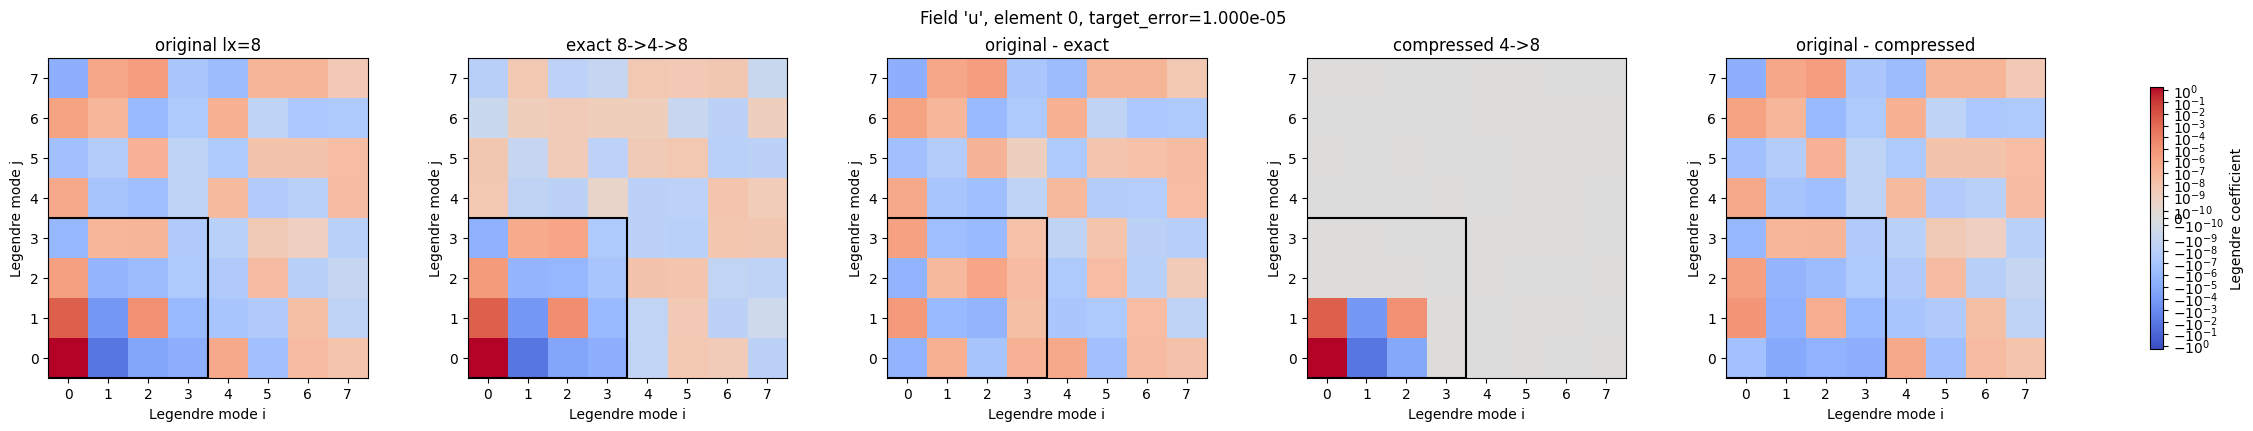

In [69]:
"""Diagnostic for an lx=8 -> lx=4 -> lx=8 Legendre round trip.

This file is intended to be run in the notebook/session where ``comm``, ``msh``,
``coef``, ``fld``, ``target_error``, and ``move_field_to_target_lx_2d`` already
exist.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.colors import SymLogNorm

from pysemtools.datatypes.coef import Coef
from pysemtools.compression.legendre_truncation_bitplane import (
    DiscreetLegendreTruncationBP,
)


def inspect_lx4_lx8_roundtrip(
    comm,
    msh,
    coef,
    fld,
    target_error,
    move_field_to_target_lx_2d,
    element=0,
    field_name="u",
    coarse_lx=4,
):
    """Compare exact and compressed coarse-grid round trips for one element."""

    u_lx8 = np.asarray(fld.registry[field_name])
    fine_lx = int(msh.lx)

    if fine_lx != 8:
        raise ValueError(f"This diagnostic expects the original field at lx=8, got lx={fine_lx}.")
    if u_lx8.shape[1] != 1:
        raise ValueError("This diagnostic assumes a 2D SEM field with lz=1.")
    if not 0 <= element < u_lx8.shape[0]:
        raise IndexError(f"element must lie in [0, {u_lx8.shape[0] - 1}].")

    # 1. Restrict the original lx=8 field to lx=4.
    msh_lx4, u_lx4 = move_field_to_target_lx_2d(
        comm=comm,
        msh_in=msh,
        field_in=u_lx8,
        target_lx=coarse_lx,
    )
    coef_lx4 = Coef(msh=msh_lx4, comm=comm)

    transform_lx8 = DiscreetLegendreTruncationBP(
        comm=comm, msh=msh, coef=coef
    )

    # 2. Exact lx=4 -> lx=8 prolongation (no compression).
    _, u_lx4_prolongated = move_field_to_target_lx_2d(
        comm=comm,
        msh_in=msh_lx4,
        field_in=u_lx4,
        target_lx=fine_lx,
    )

    # 3. Compress/reconstruct lx=4 entirely in memory, then prolongate to lx=8.
    compressor_lx4 = DiscreetLegendreTruncationBP(
        comm=comm, msh=msh_lx4, coef=coef_lx4
    )
    compressor_lx4.sample_field(
        field=u_lx4,
        field_name="u_lx4",
        target_error=target_error,
    )
    compressor_lx4.compress_samples(lossless_compressor="bzip2")
    # No I/O is required: reconstruct_field decodes the retained in-memory stream.
    u_lx4_compressed = compressor_lx4.reconstruct_field(field_name="u_lx4")

    _, u_lx4_compressed_prolongated = move_field_to_target_lx_2d(
        comm=comm,
        msh_in=msh_lx4,
        field_in=u_lx4_compressed,
        target_lx=fine_lx,
    )

    # Transform all lx=8 fields with the same lx=8 Legendre operator.
    leg_original = transform_lx8.transform_field(u_lx8, to="legendre")
    leg_exact = transform_lx8.transform_field(u_lx4_prolongated, to="legendre")
    leg_compressed = transform_lx8.transform_field(
        u_lx4_compressed_prolongated, to="legendre"
    )
    leg_exact_residual = leg_original - leg_exact
    leg_compressed_residual = leg_original - leg_compressed

    # For a 2D field, each modal spectrum is an 8 x 8 matrix indexed by (j, i).
    spectra = {
        "original lx=8": leg_original[element, 0],
        "exact 8->4->8": leg_exact[element, 0],
        "original - exact": leg_exact_residual[element, 0],
        "compressed 4->8": leg_compressed[element, 0],
        "original - compressed": leg_compressed_residual[element, 0],
    }

    rows = []
    for j in range(fine_lx):
        for i in range(fine_lx):
            rows.append(
                {
                    "j": j,
                    "i": i,
                    "original_lx8": spectra["original lx=8"][j, i],
                    "exact_8_to_4_to_8": spectra["exact 8->4->8"][j, i],
                    "exact_residual": spectra["original - exact"][j, i],
                    "compressed_4_to_8": spectra["compressed 4->8"][j, i],
                    "compressed_residual": spectra["original - compressed"][j, i],
                }
            )
    coefficient_table = pd.DataFrame(rows)

    # A common symmetric log scale makes zeros, small values, and signs visible.
    max_abs = max(np.max(np.abs(values)) for values in spectra.values())
    if max_abs == 0.0:
        max_abs = 1.0
    linthresh = max(max_abs * 1.0e-10, np.finfo(float).tiny)
    norm = SymLogNorm(
        linthresh=linthresh,
        vmin=-max_abs,
        vmax=max_abs,
    )

    fig, axes = plt.subplots(1, 5, figsize=(23, 4.2), constrained_layout=True)
    image = None
    for axis, (title, values) in zip(axes, spectra.items()):
        image = axis.imshow(values, origin="lower", cmap="coolwarm", norm=norm)
        axis.set_title(title)
        axis.set_xlabel("Legendre mode i")
        axis.set_ylabel("Legendre mode j")
        axis.set_xticks(range(fine_lx))
        axis.set_yticks(range(fine_lx))
        # Mark the modal block representable at lx=4: i,j = 0,...,3.
        axis.add_patch(
            plt.Rectangle(
                (-0.5, -0.5), coarse_lx, coarse_lx,
                fill=False, edgecolor="black", linewidth=1.5,
            )
        )
    fig.colorbar(image, ax=axes, shrink=0.82, label="Legendre coefficient")
    fig.suptitle(
        f"Field {field_name!r}, element {element}, target_error={target_error:.3e}"
    )

    weight = coef.B
    exact_rms = np.sqrt(
        np.sum((u_lx8 - u_lx4_prolongated) ** 2 * weight) / np.sum(weight)
    )
    compressed_rms = np.sqrt(
        np.sum((u_lx8 - u_lx4_compressed_prolongated) ** 2 * weight)
        / np.sum(weight)
    )
    coarse_compression_rms = np.sqrt(
        np.sum((u_lx4 - u_lx4_compressed) ** 2 * coef_lx4.B)
        / np.sum(coef_lx4.B)
    )

    print(f"Exact 8->4->8 weighted RMS:      {exact_rms:.6e}")
    print(f"Compressed lx=4 weighted RMS:    {coarse_compression_rms:.6e}")
    print(f"Compressed 4->8 vs lx=8 RMS:     {compressed_rms:.6e}")

    # In a notebook, this displays all 64 coefficient rows without truncation.
    with pd.option_context("display.max_rows", None, "display.precision", 10):
        display(coefficient_table)

    return {
        "figure": fig,
        "coefficient_table": coefficient_table,
        "spectra": spectra,
        "u_lx4": u_lx4,
        "u_lx4_compressed": u_lx4_compressed,
        "u_lx4_prolongated": u_lx4_prolongated,
        "u_lx4_compressed_prolongated": u_lx4_compressed_prolongated,
        "exact_roundtrip_rms": exact_rms,
        "coarse_compression_rms": coarse_compression_rms,
        "compressed_roundtrip_rms": compressed_rms,
    }


# Example notebook call:
# diagnostic = inspect_lx4_lx8_roundtrip(
#     comm=comm,
#     msh=msh,
#     coef=coef,
#     fld=fld,
#     target_error=target_error,
#     move_field_to_target_lx_2d=move_field_to_target_lx_2d,
#     element=0,
#     field_name="u",
# )


diagnostic = inspect_lx4_lx8_roundtrip(
    comm=comm,
    msh=msh,
    coef=coef,
    fld=fld,
    target_error=target_error,
    move_field_to_target_lx_2d=move_field_to_target_lx_2d,
    element=0,       # Change the inspected element here
    field_name="u",
)